In [1]:
import sys
sys.path.append("/home/nasia/wine-innovation-engine")
import importlib
import src.process.simulator as sim
importlib.reload(sim)
from src.process.simulator import rhs, params, run_simulation, STATE_NAMES
import numpy as np
import matplotlib.pyplot as plt
from src.process.simulator import rhs, params, run_simulation, STATE_NAMES




In [2]:
sol = run_simulation()        # default params, t_end = 600 h
t = sol.t
X, Xt, S, N, E = sol.y

print(f"Solver succeeded: {sol.success}")
print(f"Time points: {len(t)}  |  span: {t[0]:.0f}–{t[-1]:.0f} h")

Solver succeeded: True
Time points: 604  |  span: 0–600 h


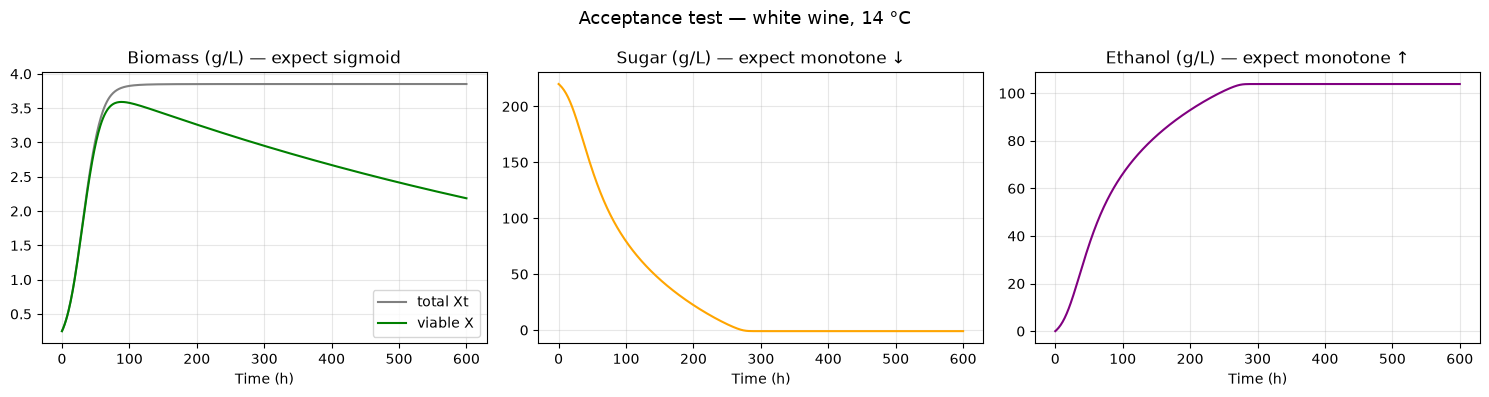

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Acceptance test — white wine, 14 °C", fontsize=13)

ax[0].plot(t, Xt, color="gray", label="total Xt")
ax[0].plot(t, X, color="green", label="viable X")
ax[0].set_title("Biomass (g/L) — expect sigmoid")
ax[0].legend()

ax[1].plot(t, S, color="orange")
ax[1].set_title("Sugar (g/L) — expect monotone ↓")

ax[2].plot(t, E, color="purple")
ax[2].set_title("Ethanol (g/L) — expect monotone ↑")

for a in ax:
    a.set_xlabel("Time (h)"); a.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


 CODE TEST: RK45 SOLVER maybe has some noise and not real increasement of sugar ,so we put 1e-6
 

In [4]:
tol=1e-6 #we say It's okay if the biomass drops slightly between measurements, as long as the drop isn't larger than the tolerance

sugar_ok=np.all(np.diff(S) <=tol) #sugar never increases
ethanol_ok=np.all(np.diff(E) >=-tol) #ethanol never decreases
sigmoid_ok=np.all(np.diff(Xt) >=-tol)#total biomass monotone->plateau 

print(f"Sugar monotonically decreasing : {sugar_ok}")
print(f"Ethanol monotonically increasing: {ethanol_ok}")
print(f"Total biomass monotone (sigmoid): {sigmoid_ok}")

assert sugar_ok and ethanol_ok and sigmoid_ok, "Acceptance test FAILED — debug before moving on."
print("\n✅ Acceptance test PASSED")

Sugar monotonically decreasing : True
Ethanol monotonically increasing: True
Total biomass monotone (sigmoid): True

✅ Acceptance test PASSED


In [6]:
final_ethanol = E[-1]
abv = final_ethanol / 7.89                       # g/L → % v/v (ethanol ρ ≈ 0.789 g/mL)
residual_sugar = max(S[-1],0.0)  # g/L, avoid negative values due to numerical noise

# time to "dry" (residual sugar < 4 g/L, oenological dryness threshold)
dry_idx = np.argmax(S < 4.0) if np.any(S < 4.0) else -1
time_to_dry = t[dry_idx] if dry_idx != -1 else np.nan

print(f"Final ethanol   : {final_ethanol:6.1f} g/L  (≈ {abv:.1f} % v/v)")
print(f"Residual sugar  : {residual_sugar:6.1f} g/L")
print(f"Time to dryness : {time_to_dry:6.0f} h  (≈ {time_to_dry/24:.1f} days)")

Final ethanol   :  103.9 g/L  (≈ 13.2 % v/v)
Residual sugar  :    0.0 g/L
Time to dryness :    255 h  (≈ 10.6 days)


Final sugar:         -1.0 g/L   (paper: ~50, stuck)
Final viable biomass: 2.19 g/L
Max viable biomass:  3.59 g/L   (paper: ~3.5)


FileNotFoundError: [Errno 2] No such file or directory: 'results/figures/fermentation_simulation_with_maintenance_concentrations_not_bellow_zero.png'

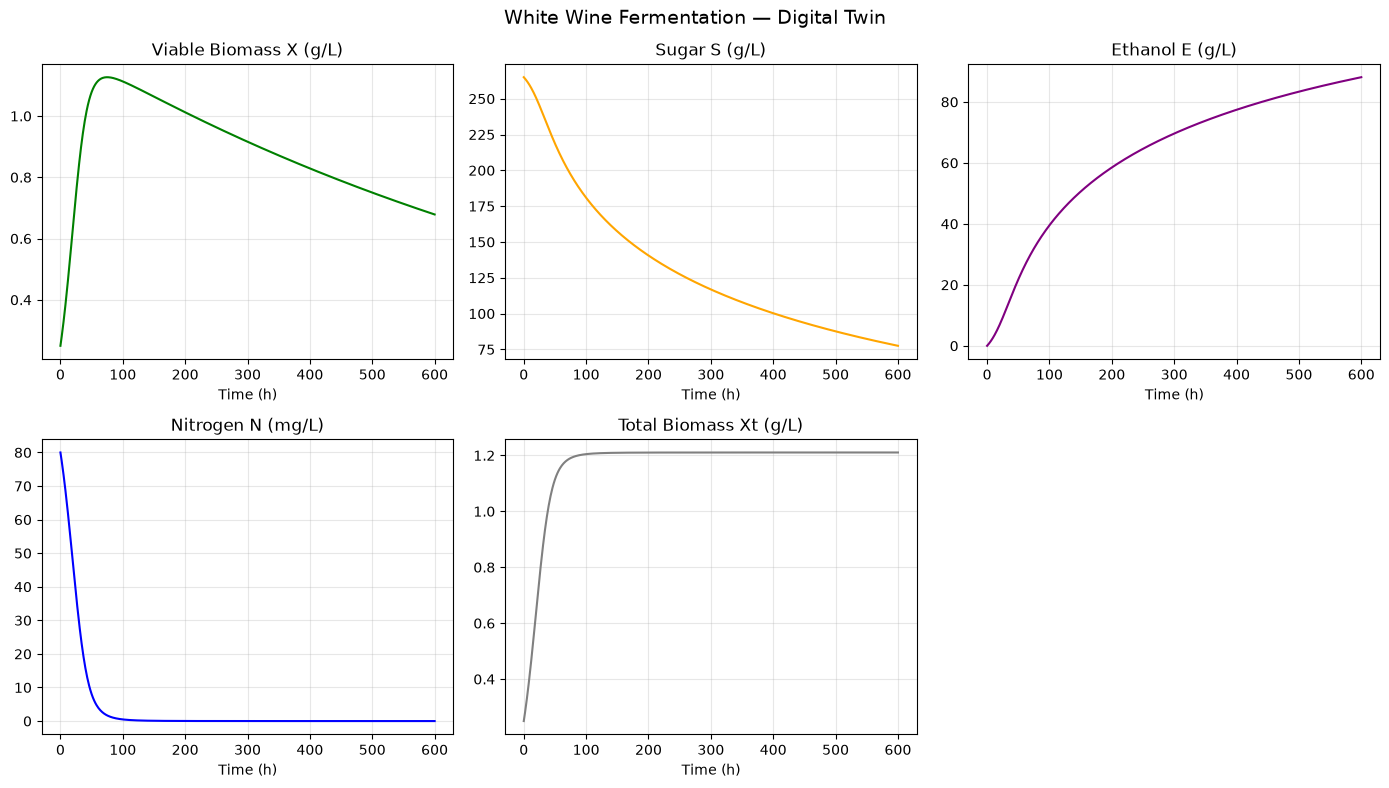

In [9]:
## Validation against Coleman Dataset 2 (Fermentation 10:269, Figure 2)
# Paper conditions: 265 g/L sugar, 80 mg/L N, 15°C
# Paper result: STUCK fermentation, ~50 g/L sugar remaining, max biomass ~3.5 g/L


from src.process.simulator import run_simulation,params,plot_simulation

p_test={**params,"S0": 265.0, "N0": 80.0, "T": 15.0} #we do this way to not change the default params in the simulator.py file, but just for this test
sol_test=run_simulation(p_test) #run the simulation with the test parameters

print("Final sugar:        ", round(sol.y[2, -1], 1), "g/L   (paper: ~50, stuck)")
print("Final viable biomass:", round(sol.y[0, -1], 2), "g/L")
print("Max viable biomass: ", round(sol.y[0].max(), 2), "g/L   (paper: ~3.5)")

plot_simulation(sol_test)


in the paper they getting stuck but mine consumes all the sugar because we add it the maintenance term that eat sugan even after growth stops 